02 - Exploratory Data Analysis

This notebook explores churn patterns using the cleaned dataset.


Set Up

In [20]:
# Importing Necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [21]:
# Load the clean processed data

df = pd.read_csv(
    r"D:\Datasets\Research\Customer Churn\Telco Customer Churn\telco_cleaned.csv"
)

df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
# Convert the churn columns to numeric and add to the dataframe as a new column
df['Churn_numeric'] = df['Churn'].map({'No' : 0, 'Yes' : 1})

## Overall Churn Rate (Baseline KPI)

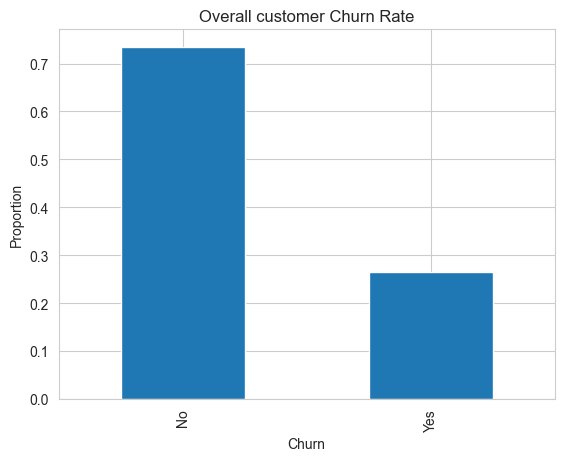

In [23]:
churn_rate = df['Churn'].value_counts(normalize=True)

churn_rate.plot(
    kind = 'bar',
    title = 'Overall customer Churn Rate'
)
plt.ylabel('Proportion')

# Save the plot
plt.savefig(r'D:/Datasets/Research/Customer Churn/Telco Customer Churn/overall_churn_rate.png',
            dpi = 300,
            bbox_inches = 'tight')

plt.show()

Insight

Approximately 30% of customers have churned, indicating a non-tivial retention problem.

## Churn Vs Contract Type

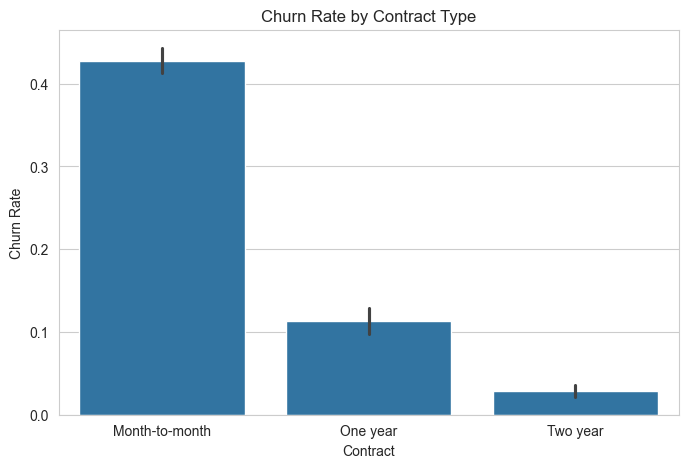

In [24]:
plt.figure(figsize = (8,5))
sns.barplot(
    data = df,
    x = 'Contract',
    y = 'Churn_numeric',
    estimator = 'mean'
)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')

# Save the plot
plt.savefig(r'D:/Datasets/Research/Customer Churn/Telco Customer Churn/churn_rate_by_contract_type.png',
            dpi = 300,
            bbox_inches = 'tight')

plt.show()

Insight

Month-to-month contracts have significantly higher churn compared to one- and two-year contracts.

## Tenure Distribution by Churn

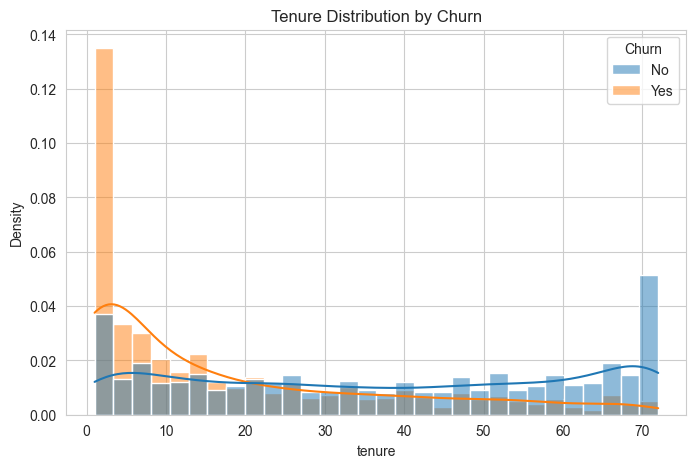

In [25]:
plt.figure(figsize = (8,5))
sns.histplot(
    data = df,
    x = 'tenure',
    hue = 'Churn',
    bins = 30,
    kde = True,
    stat = 'density',
    common_norm = False
)

plt.title('Tenure Distribution by Churn')

# Save the plot
plt.savefig(r'D:/Datasets/Research/Customer Churn/Telco Customer Churn/tenure_distribution_by_churn.png',
            dpi = 300,
            bbox_inches = 'tight')

plt.show()

Insight

Customers who churn tend to have much shorter tenure highlighting early-life churn risk.

## Monthly Charges Vs Churn

This is for price sensitivity analysis

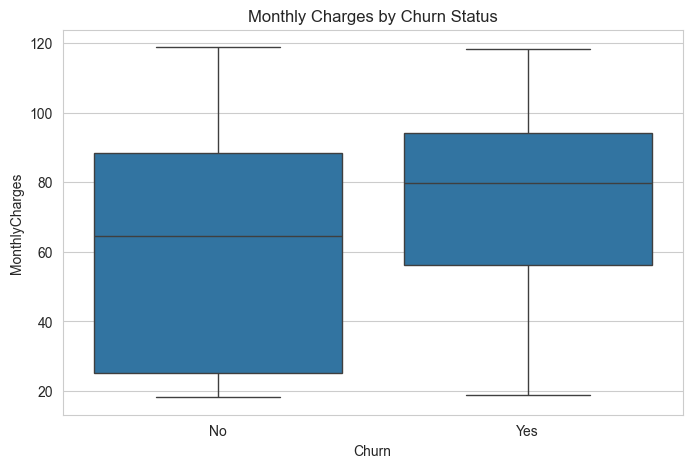

In [26]:
plt.figure(figsize = (8,5))
sns.boxplot(
    data = df,
    x = 'Churn',
    y = 'MonthlyCharges'
)
plt.title('Monthly Charges by Churn Status')

# Save the plot
plt.savefig(r'D:/Datasets/Research/Customer Churn/Telco Customer Churn/monthly_charges_by_churn_status.png',
            dpi = 300,
            bbox_inches = 'tight')

plt.show()

Insight

Churned customers generally have higher monthly charges, suggesting price sensitivity.

## Internet Services Vs Churn

This reveals product-level insight.

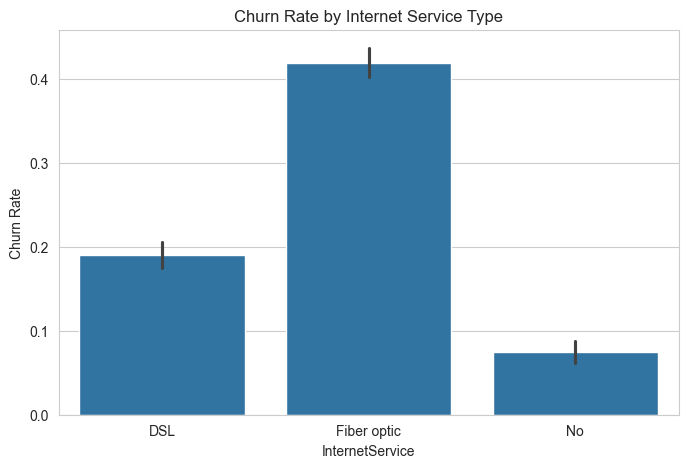

In [27]:
plt.figure(figsize = (8,5))
sns.barplot(
    data = df,
    x = 'InternetService',
    y = 'Churn_numeric',
    estimator = 'mean'
)
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate')

# Save the plot
plt.savefig(r'D:/Datasets/Research/Customer Churn/Telco Customer Churn/churn_rate_by_internet_service_type.png',
            dpi = 300,
            bbox_inches = 'tight')

plt.show()

Insight

Fibre optic customers show higher churn rates, possibly due to pricing or service expectations.

## Payment Method Vs Churn

This provides operational insight (billing friction)

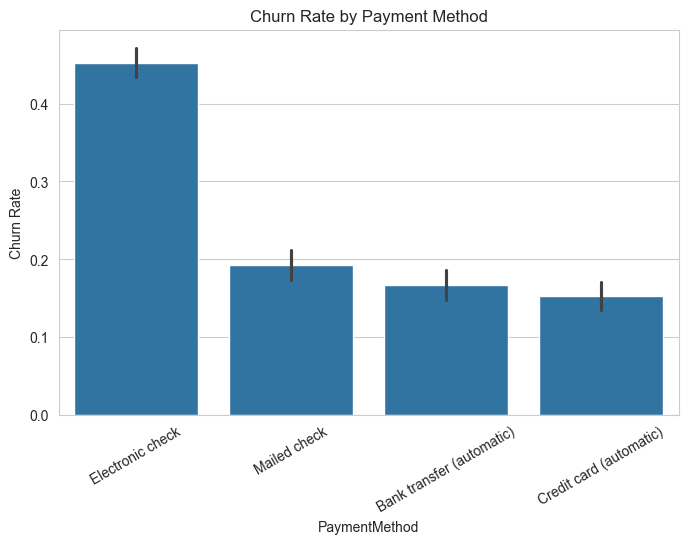

In [28]:
plt.figure(figsize = (8,5))
sns.barplot(
    data = df,
    x = 'PaymentMethod',
    y = 'Churn_numeric',
    estimator = 'mean'
)

plt.xticks(rotation = 30)
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')

# Save the plot
plt.savefig(r'D:/Datasets/Research/Customer Churn/Telco Customer Churn/churn_rate_by_payment_method.png',
            dpi = 300,
            bbox_inches = 'tight')

plt.show()

Insight

Electronic check users churn more frequently, indicating potential billing friction or lower commitment.

## Correlation Heatmap

This is to prepare for modelling, avoid leakage.

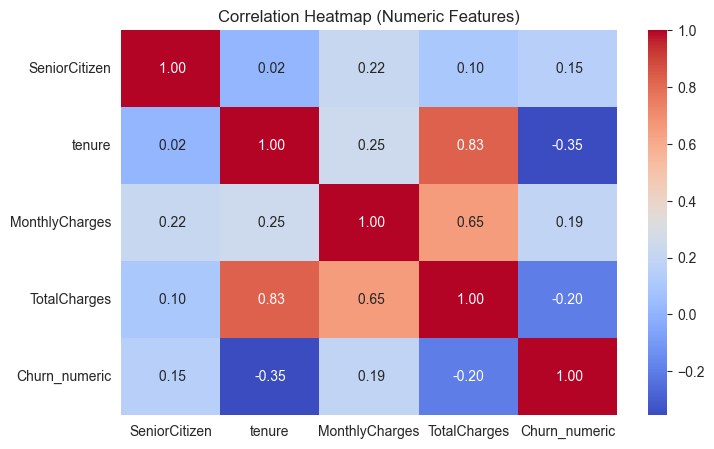

In [29]:
# Drop the index column 'Unnamed' 
df = df.drop(columns = ['Unnamed: 0'])

# Select all the numeric columns
numeric_cols = df.select_dtypes(include = 'number')

# Exclude churn_numeric
# numeric_cols = numeric_cols.drop(columns = ['Churn_numeric'])

plt.figure(figsize = (8,5))
sns.heatmap(
    numeric_cols.corr(),
    annot = True,
    fmt = " .2f",
    cmap = "coolwarm"
)
plt.title('Correlation Heatmap (Numeric Features)')

# Save the plot
plt.savefig(r'D:/Datasets/Research/Customer Churn/Telco Customer Churn/correlation_heatmap.png',
            dpi = 300,
            bbox_inches = 'tight')

plt.show()

Insight

Tenure is strongly negatively correlated with churn, reinforcing lifecycle effects.

### Key EDA Insights

- Month-to-month contracts are the strongest churn driver.

- Short-tenure customers are at highest risk.

- Higher monthly charges correlate with churn.

- Billing method impacts retention.

### README from EDA

Exploratory analysis revealed that churn is highest among customers with short tenure, month-to-month contracts, higher monthly charges, and electronic payment methods. These findings guided feature engineering and model selection.